# Practice Question (Midterm 2)


## Problem 1: Symbolic Algebra 

Work in pairs to solve the following problems. Given this function:

$$
f(x) = \frac{d^5}{dx^5} \left( x \sin(x) \right)
$$

1. Find $f(x)$
2. Graph $f(x)$
3. Find at lesat one non-trivial root of $f(x)$

In [93]:
from sympy import *
from scipy.optimize import fsolve
import numpy as np
import matplotlib.pyplot as plt

In [94]:
x = symbols("x")
g = x*sin(x)
f = g.diff(x,5)
f

x*cos(x) + 5*sin(x)

In [95]:
f.subs(x, 26.8847)

0.0742744122118149

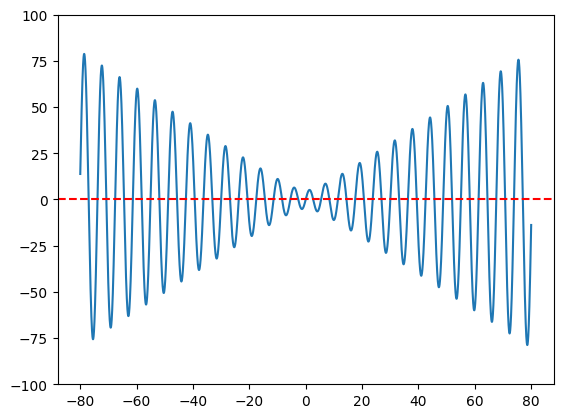

In [96]:
f_num = lambdify(x, f)
x_vec = np.linspace(-80,80,50000)
fig, ax = plt.subplots()
ax.plot(x_vec, f_num(x_vec))
ax.set_ylim((-100,100))
ax.axhline(y=0, color='red', ls='--')
plt.show()

In [97]:
sols = list()
for i in range(10):
    x0 = i*3
    x_sol = fsolve(f_num, x0)[0]
    sols.append(x_sol)
sols = set(sols)  # only keep unique solutions
print(f"{len(sols)} solutions are:")
[(round(x,4),round(f_num(x),10)) for x in sols]

10 solutions are:


[(0.0, 0.0),
 (2.6537, 0.0),
 (5.4544, 0.0),
 (8.3913, -0.0),
 (11.4086, -0.0),
 (14.4699, 0.0),
 (17.5562, 0.0),
 (20.6578, 0.0),
 (23.7693, -0.0),
 (26.8874, -0.0)]

## Problem 2: Newton-Raphson Method

Given the following function

$$
f(x,b)=\sqrt{x+1}−\sqrt{x} − b
$$

Implement the Newton-Raphson Method to find a root of $f(x,10^{−5})$ using a smart choice of starting point.  (You can use the `sympy` to find the derivative.) The Newton-Raphson algorithm is implemented with $x_{n+1} = x_n - f(x_n)/(f'(x_n))$.

In [98]:
x, b = symbols("x b")
f = sqrt(x+1) - sqrt(x) - b
f.diff(x)

1/(2*sqrt(x + 1)) - 1/(2*sqrt(x))

In [99]:
def f(x):
    return np.sqrt(x+1)-np.sqrt(x)-0.01
def df(x):
    return (1/(2*np.sqrt(x+1)) - 1/(2*np.sqrt(x)))

In [100]:
n=0
eps=1e-12
x0 = 1000
while n<1000 and abs(f(x0))>eps:
    n=n+1
    xn = x0 - f(x0)/df(x0)
    x0 = xn
print(f"After {n} steps, found {x0}")

After 5 steps, found 2499.5000246773393
